## Description
This notebook demonstrates how to compute the SW ERFaci from ice clouds using cloud radiative kernels using the difference between piClim-aer vs piClim-control simulations. Additionally, this script demonstrates how to compute the decomposition of ERFaci into components due to changes in cloud amount, effective radius, ice water path, and a residual. This notebook and associated python code was adapted from the ISCCP CRK approach of Mark Zelinka, and largely follows the process outlined there.

## Input
- ts,clmodis_iwpr,fsdsc,fsnsc (surface temperature, new MODIS re-IWP joint histogram, Clearsky downwelling solar flux at surface, Clearsky net solar flux at surface)
- cloud radiative kernel

## References
- Zelinka, M. D., S. A. Klein, and D. L. Hartmann, 2012: [Computing and Partitioning Cloud Feedbacks Using 
    Cloud Property Histograms. Part I: Cloud Radiative Kernels](http://journals.ametsoc.org/doi/abs/10.1175/JCLI-D-11-00248.1). J. Climate, 25, 3715-3735. 
    doi:10.1175/JCLI-D-11-00248.1.
- Zelinka, M. D., S. A. Klein, and D. L. Hartmann, 2012: [Computing and Partitioning Cloud Feedbacks Using 
    Cloud Property Histograms. Part II: Attribution to Changes in Cloud Amount, Altitude, and Optical Depth](http://journals.ametsoc.org/doi/abs/10.1175/JCLI-D-11-00249.1). 
    J. Climate, 25, 3736-3754. doi:10.1175/JCLI-D-11-00249.1.
- Zelinka, M.D., S.A. Klein, K.E. Taylor, T. Andrews, M.J. Webb, J.M. Gregory, and P.M. Forster, 2013: 
    [Contributions of Different Cloud Types to Feedbacks and Rapid Adjustments in CMIP5](http://journals.ametsoc.org/doi/abs/10.1175/JCLI-D-12-00555.1). 
    J. Climate, 26, 5007-5027. doi:10.1175/JCLI-D-12-00555.1.
- Zelinka et al. (2022): [Evaluating climate models’ cloud feedbacks against expert judgement](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2021JD035198), _J. Geophys. Res._, 127, e2021JD035198, doi:10.1029/2021JD035198.
    
## Contact
- Brandon Duran (bmduran@ucsd.edu)

## Import useful functions

In [1]:
import sys 
import os
import calc_IceCRK as CRK
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import numpy as np
import warnings
import copy
xr.set_options(use_new_combine_kwarg_defaults=True)

In [4]:
def do_aci_fig(output):
    sec = 'ALL' # Use the full histogram
    DS = xr.Dataset(output[sec])
    avgmap = DS.mean('time')
    avgmap=avgmap.bounds.add_missing_bounds()
    fig = plt.figure(figsize = (16,7))
    plt.suptitle('SW ERFaci from ice clouds',fontsize=18,x=0.43,y=0.95)
    axes = fig.subplots(nrows=2, ncols=3, subplot_kw={'projection': ccrs.Robinson(central_longitude=180)})
    fields = list(DS.data_vars)
    cnt=-1
    for row in range(2):
        for col in range(3):
            cnt+=1
            if row == 1 and col == 2:    continue
            var = fields[cnt]
            avg = avgmap.spatial.average(var, axis=["X", "Y"])[var].values
            pl = avgmap[var].plot(ax = axes[row,col], 
                      transform=ccrs.PlateCarree(),
                      vmin = -4, vmax = 4,
                      cmap = 'RdBu_r', extend='both',                              
                      add_colorbar=False)
            axes[row,col].set_title('{} ({:.3f})'.format(var,avg),size=15)
            axes[row,col].coastlines()
    plt.tight_layout()
    fig.delaxes(axes[1,2])
    c=fig.colorbar(pl, ax=axes.ravel().tolist(), pad = 0.02, shrink = 0.65, aspect = 15, label=r"$Wm^{-2}$")
    c.set_label
    plt.show()
    return DS

get data
PI
  TS
  CLMODIS_IWPR
  FSDSC
  FSNSC
PD
  TS
  CLMODIS_IWPR
  FSDSC
  FSNSC


2025-11-06 08:15:27,568 [WARNING]: bounds.py(create_bounds:931) >> The 'lat' coordinate variable is missing a 'units' attribute. Assuming 'units' is 'degrees_north'.
2025-11-06 08:15:27,568 [WARNING]: bounds.py(create_bounds:931) >> The 'lat' coordinate variable is missing a 'units' attribute. Assuming 'units' is 'degrees_north'.


get SW kernel
Compute SW ERFaci,ice and its components


2025-11-06 08:17:08,848 [WARNING]: bounds.py(create_bounds:931) >> The 'lat' coordinate variable is missing a 'units' attribute. Assuming 'units' is 'degrees_north'.
2025-11-06 08:17:08,848 [WARNING]: bounds.py(create_bounds:931) >> The 'lat' coordinate variable is missing a 'units' attribute. Assuming 'units' is 'degrees_north'.


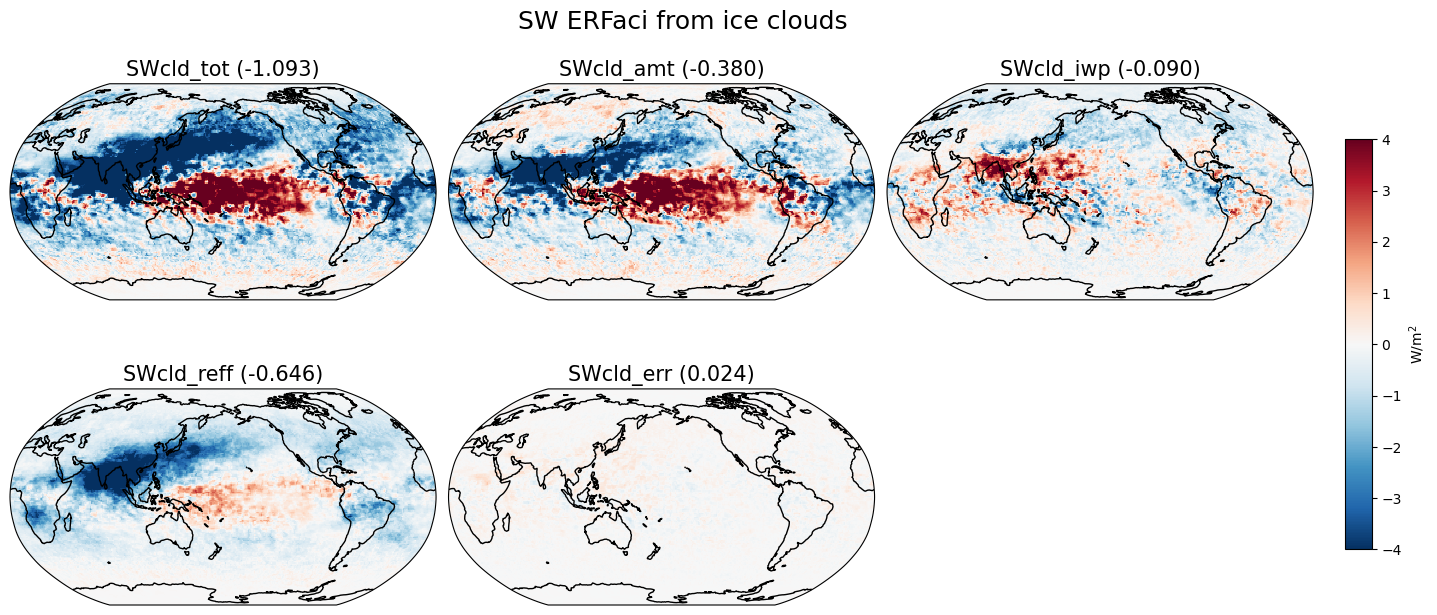

In [3]:
variables = ['TS', 'CLMODIS_IWPR', 'FSDSC', 'FSNSC']
exps = ['PI','PD']
datadir = "../data/"
save_netcdf = False
outpath = datadir + 'ERFaci-ice.nc'
# Get filepaths
filepath={}
for exp in exps:
    filepath[exp]={}   
    for var in variables:
        filepath[exp][var]={}
        filepath[exp][var] = f'{datadir}/{exp}/{var}.nc'

# Do ERFaci calculations
output = CRK.CloudRadKernel(filepath)#, False) #for feedbacks

# Make Figure
DS = do_aci_fig(output)

# Save 
if save_netcdf:
    print(outpath)
    DS.to_netcdf(outpath)